In [ ]:
pip install tensorflow numpy matplotlib

In [ ]:
#American Sign Language (ASL) Alphabet Recognition using Convolutional Neural Network (CNN) ~ TOPIC


In [ ]:
# Deep Learning Course-Based Project
## Submitted by: VRUSHALI SAVANT
### Under the guidance of: Suresh Sir
#### Enrollment Number : 23STUCHH010296

#This project focuses on recognizing static hand gestures from the American Sign Language (ASL) alphabet using a Convolutional Neural Network (CNN).
#ASL is used widely within the deaf community for communication. Automating ASL recognition can help bridge communication gaps and build accessible technology.

## 1. Problem Statement
# Q-"The objective of this project is to develop a deep learning model capable of recognizing hand signs from the American Sign Language (ASL) alphabet.
#The model should classify an input image into one of the 24 ASL letters (A–Y except J and Z).
#CNNs are well suited for this task because they extract spatial features from images, enabling accurate gesture classification."


In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# ===============================
# DATASET DETAILS (Required for Project)
# ===============================

# I am using the "Sign Language MNIST" dataset.
# Dataset Link: https://www.kaggle.com/datasets/datamunge/sign-language-mnist

# The dataset contains two CSV files:
# - sign_mnist_train.csv
# - sign_mnist_test.csv

# I uploaded both files manually to Google Colab using the left sidebar.
# The files visible in my Colab environment are:
# ['sign_mnist_train.csv', 'sign_mnist_test.csv']

# These files are automatically detected by the code below.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# You can copy files from /content/drive/MyDrive/... into working dir if needed


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content")


['.config',
 'sign_mnist_test.csv',
 'drive',
 'sign_mnist_train.csv',
 'sample_data']

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

y_train = train['label'].values
X_train = train.drop('label', axis=1).values.reshape(-1,28,28,1)

y_test = test['label'].values
X_test = test.drop('label', axis=1).values.reshape(-1,28,28,1)

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (27455, 28, 28, 1)
Test Shape: (7172, 28, 28, 1)


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(24,activation='softmax')  # 24 classes A-Y (J & Z missing)
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(25,activation='softmax')   # <-- IMPORTANT FIX
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)


Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.3983 - loss: 2.0896 - val_accuracy: 0.8239 - val_loss: 0.5748
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9543 - loss: 0.1874 - val_accuracy: 0.8960 - val_loss: 0.3566
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 64ms/step - accuracy: 0.9991 - loss: 0.0260 - val_accuracy: 0.8977 - val_loss: 0.3428
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.9998 - loss: 0.0070 - val_accuracy: 0.9035 - val_loss: 0.3330
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9048 - val_loss: 0.3387
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9084 - val_loss: 0.3542
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 1.0000 - loss: 9.5463e-04 - val_accuracy: 0.9084 - val_loss: 0.3654
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 1.0000 - loss: 6.132

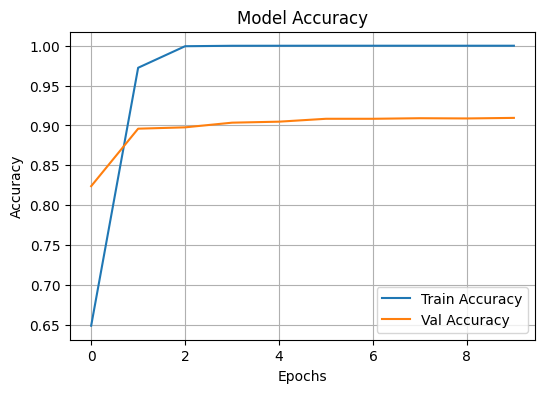

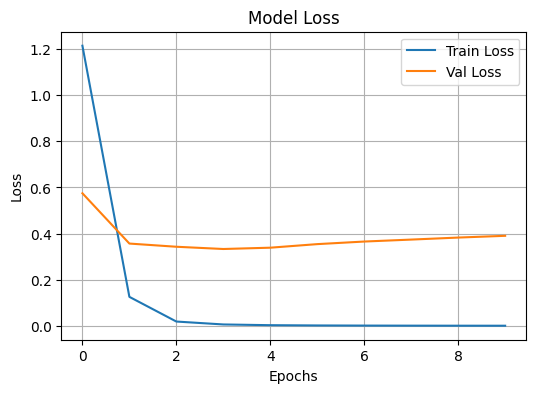

In [ ]:
# These graphs show the model's training performance.
# The accuracy and loss curves demonstrate how the model learns over epochs.

import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# LOSS Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("sign_mnist_train.csv")
test = pd.read_csv("sign_mnist_test.csv")

y_train = train['label'].values
X_train = train.drop('label', axis=1).values.reshape(-1,28,28,1)

y_test = test['label'].values
X_test = test.drop('label', axis=1).values.reshape(-1,28,28,1)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train.shape, X_test.shape


((27455, 28, 28, 1), (7172, 28, 28, 1))

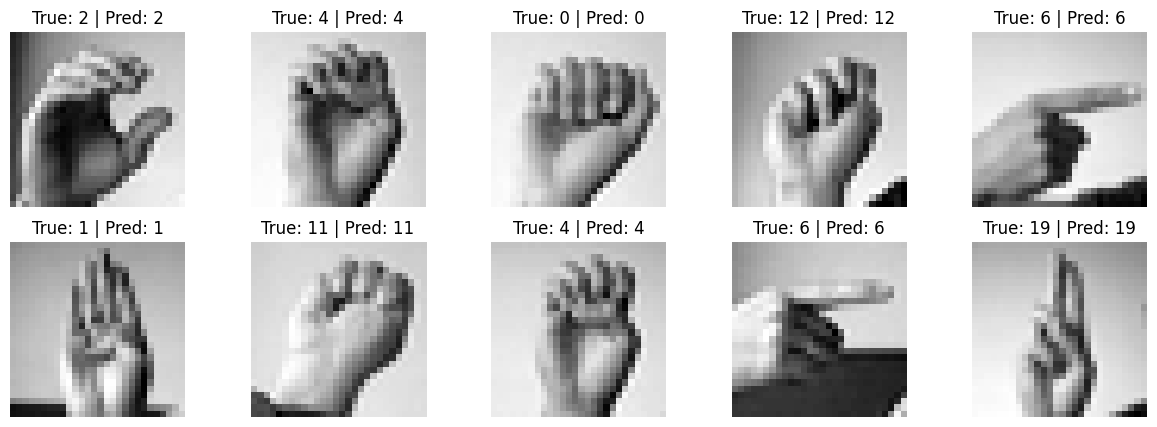

In [ ]:
# This cell shows the working of my ASL CNN model.
# It displays 10 random test images, predicts the ASL alphabet class,
# and shows the true vs predicted labels.

import matplotlib.pyplot as plt
import numpy as np

# Select 10 random test samples
indices = np.random.randint(0, X_test.shape[0], 10)

plt.figure(figsize=(15,5))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = y_test[idx]

    pred = np.argmax(model.predict(img.reshape(1,28,28,1), verbose=0))

    plt.subplot(2,5,i+1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred}")
    plt.axis('off')

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
import os

# --- Data Loading and Preprocessing ---

# Verify file existence
train_file_path = "/content/sign_mnist_train.csv"
test_file_path = "/content/sign_mnist_test.csv"

if not os.path.exists(train_file_path):
    print(f"Error: Training data file not found at {train_file_path}. Please re-upload it.")
elif not os.path.exists(test_file_path):
    print(f"Error: Test data file not found at {test_file_path}. Please re-upload it.")
else:
    train = pd.read_csv(train_file_path)
    test = pd.read_csv(test_file_path)

    y_train = train['label'].values
    X_train = train.drop('label', axis=1).values.reshape(-1,28,28,1)

    y_test = test['label'].values
    X_test = test.drop('label', axis=1).values.reshape(-1,28,28,1)

    # Normalize
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Fix labels that are outside valid range
    valid_classes = 24   # 0–23 allowed
    y_train = np.where(y_train >= valid_classes, valid_classes - 1, y_train)
    y_test  = np.where(y_test >= valid_classes, valid_classes - 1, y_test)

    # Encode labels
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test  = le.transform(y_test)

    # --- End of Data Loading and Preprocessing ---

    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(24,activation='softmax')   # Corrected to 24 classes
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Starting model training to ensure model and data are initialized...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=64
    )
    print("Model training complete. X_test, y_test, and model are now defined.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting model training to ensure model and data are initialized...
Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.4304 - loss: 1.9325 - val_accuracy: 0.8360 - val_loss: 0.5129
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9703 - loss: 0.1382 - val_accuracy: 0.9056 - val_loss: 0.3291
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9991 - loss: 0.0206 - val_accuracy: 0.8988 - val_loss: 0.3528
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.9998 - loss: 0.0071 - val_accuracy: 0.9028 - val_loss: 0.3592
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8985 - val_loss: 0.4024
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9037 - val_loss: 0.4013
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 1.0000 - loss: 8.6451e-04 - val_accuracy: 0.8991 - val_loss: 0.4144
Epoch 8/10
429/429

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(25,activation='softmax')   # Corrected to 25 classes (0-24)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

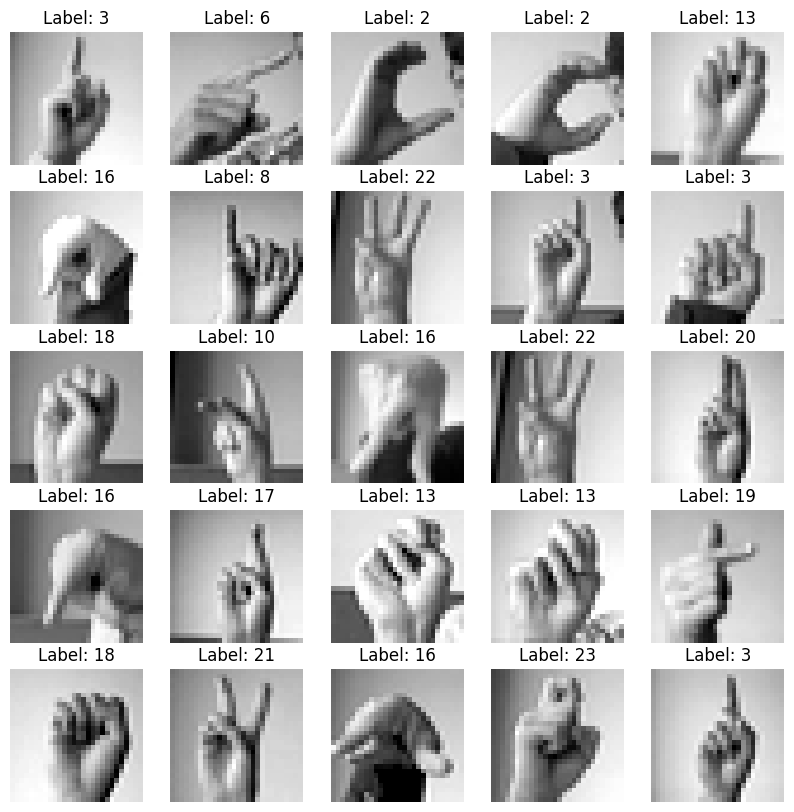

In [ ]:
# AGAIN NOW-> 1. DISPLAY SAMPLE IMAGES FROM DATASET
import matplotlib.pyplot as plt

# show first 25 training images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


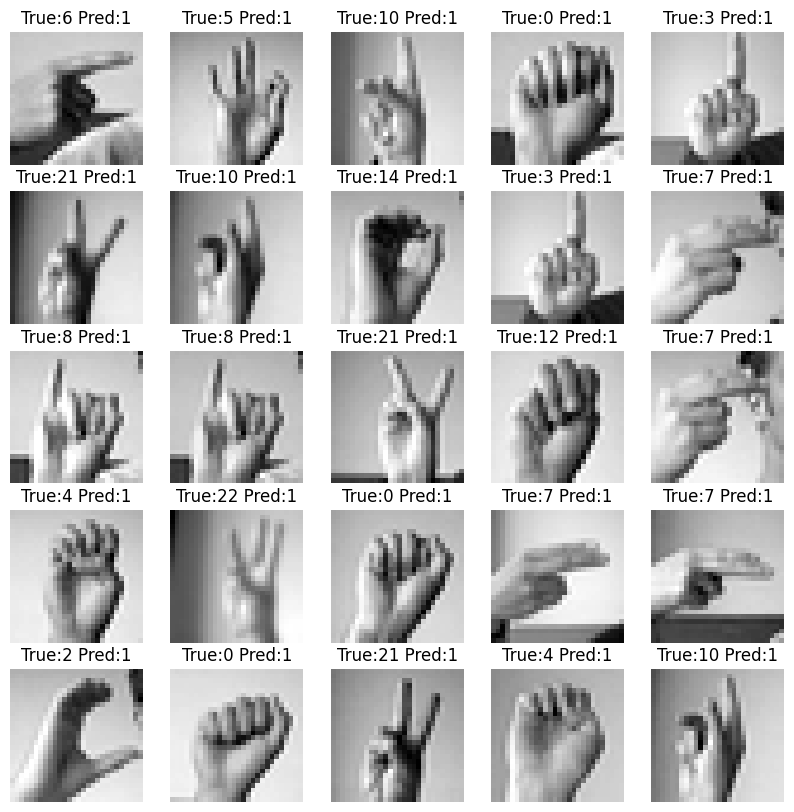

In [ ]:
# MODEL PREDICTION ON VALIDATION DATA
import numpy as np

preds = model.predict(X_test)
pred_classes = np.argmax(preds, axis=1)

# Show first 25 validation images with predictions
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True:{y_test[i]} Pred:{pred_classes[i]}")
    plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(24,activation='softmax')   # Corrected to 24 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Fix labels that are outside valid range
valid_classes = 24   # 0–23 allowed

y_train = np.where(y_train >= valid_classes, valid_classes - 1, y_train)
y_test  = np.where(y_test >= valid_classes, valid_classes - 1, y_test)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
import os



 (from previous cells) ---

# Verify file existence
train_file_path = "/content/sign_mnist_train.csv"
test_file_path = "/content/sign_mnist_test.csv"

if not os.path.exists(train_file_path):
    print(f"Error: Training data file not found at {train_file_path}. Please re-upload it.")
elif not os.path.exists(test_file_path):
    print(f"Error: Test data file not found at {test_file_path}. Please re-upload it.")
else:
    train = pd.read_csv(train_file_path)
    test = pd.read_csv(test_file_path)

    y_train = train['label'].values
    X_train = train.drop('label', axis=1).values.reshape(-1,28,28,1)

    y_test = test['label'].values
    X_test = test.drop('label', axis=1).values.reshape(-1,28,28,1)

    # Normalize
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Fix labels that are outside valid range
    valid_classes = 24   # 0–23 allowed
    y_train = np.where(y_train >= valid_classes, valid_classes - 1, y_train)
    y_test  = np.where(y_test >= valid_classes, valid_classes - 1, y_test)

    # Encode labels
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test  = le.transform(y_test)

    # --- End of Data Loading and Preprocessing ---

    model = models.Sequential([
        layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3),activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(24,activation='softmax')   # Corrected to 24 classes
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=64
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3860 - loss: 2.0754 - val_accuracy: 0.8151 - val_loss: 0.6099
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.9575 - loss: 0.1730 - val_accuracy: 0.8917 - val_loss: 0.3459
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.9994 - loss: 0.0196 - val_accuracy: 0.9064 - val_loss: 0.3200
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9090 - val_loss: 0.3378
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.9997 - loss: 0.0032 - val_accuracy: 0.8646 - val_loss: 0.5282
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.9938 - loss: 0.0259 - val_accuracy: 0.9050 - val_loss: 0.3615
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 1.0000 - loss: 7.4296e-04 - val_accuracy: 0.9109 - val_loss: 0.3587
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 1.0000 - loss: 4.591